# Assignment 2 — Question 2: SVM

Dataset: `mobile_price.csv` (2000 samples, 20 features, 4 balanced classes `price_range ∈ {0,1,2,3}`).

Target: predict `price_range` with `sklearn.svm.SVC`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

os.makedirs('chart', exist_ok=True)

SEED = 42

## Load & split (shuffle `random_state=42`, 60/20/20 train/val/test)

In [2]:
df = pd.read_csv('data/mobile_price.csv')
X = df.drop(columns=['price_range']).values.astype(float)
y = df['price_range'].values

# 60/20/20: first carve off 20% test, then split remaining 80% into 60/20 (i.e. 0.25 of the 80%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED, shuffle=True, stratify=y_trainval
)

print(f'Train: {X_train.shape},  Val: {X_val.shape},  Test: {X_test.shape}')
print(f'Class balance — train: {np.bincount(y_train)},  val: {np.bincount(y_val)},  test: {np.bincount(y_test)}')

Train: (1200, 20),  Val: (400, 20),  Test: (400, 20)
Class balance — train: [300 300 300 300],  val: [100 100 100 100],  test: [100 100 100 100]


## Q2(a) — SVC with `C = 1.0`

SVM is scale-sensitive (`battery_power ≈ 1000s`, `clock_speed < 3`), so features are standardised inside a `Pipeline`. The scaler is fit only on the training split to avoid leakage.

In [3]:
def build_svc(C):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(C=C, random_state=SEED)),
    ])

def eval_split(model, X, y):
    y_pred = model.predict(X)
    return accuracy_score(y, y_pred), f1_score(y, y_pred, average='macro')

model = build_svc(C=1.0)
model.fit(X_train, y_train)

tr_acc, tr_f1 = eval_split(model, X_train, y_train)
va_acc, va_f1 = eval_split(model, X_val,   y_val)
te_acc, te_f1 = eval_split(model, X_test,  y_test)

print(f'{"Split":<8}{"Accuracy":>12}{"Macro F1":>12}')
print('-'*32)
print(f'{"Train":<8}{tr_acc:>12.4f}{tr_f1:>12.4f}')
print(f'{"Val":<8}{va_acc:>12.4f}{va_f1:>12.4f}')
print(f'{"Test":<8}{te_acc:>12.4f}{te_f1:>12.4f}')

Split       Accuracy    Macro F1
--------------------------------
Train         0.9842      0.9842
Val           0.8700      0.8698
Test          0.8725      0.8727


## Q2(b) — Sweep `C ∈ {1e-3 … 1e4}` and visualise

For each C value, train on the training split and evaluate Accuracy + macro-F1 on **all three** splits.

In [4]:
C_values = [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000, 10000]

records = []
for C in C_values:
    m = build_svc(C=C)
    m.fit(X_train, y_train)
    tr_a, tr_f = eval_split(m, X_train, y_train)
    va_a, va_f = eval_split(m, X_val,   y_val)
    te_a, te_f = eval_split(m, X_test,  y_test)
    records.append({
        'C': C,
        'train_acc': tr_a, 'val_acc': va_a, 'test_acc': te_a,
        'train_f1':  tr_f, 'val_f1':  va_f, 'test_f1':  te_f,
    })

sweep_df = pd.DataFrame(records)
print(sweep_df.round(4).to_string(index=False))

        C  train_acc  val_acc  test_acc  train_f1  val_f1  test_f1
    0.001     0.7842   0.7075    0.6625    0.7884  0.7167   0.6735
    0.010     0.7842   0.7075    0.6625    0.7884  0.7167   0.6735
    0.100     0.7858   0.7075    0.6625    0.7902  0.7167   0.6730
    1.000     0.9842   0.8700    0.8725    0.9842  0.8698   0.8727
   10.000     1.0000   0.8500    0.8725    1.0000  0.8491   0.8718
  100.000     1.0000   0.8500    0.8725    1.0000  0.8491   0.8718
 1000.000     1.0000   0.8500    0.8725    1.0000  0.8491   0.8718
10000.000     1.0000   0.8500    0.8725    1.0000  0.8491   0.8718


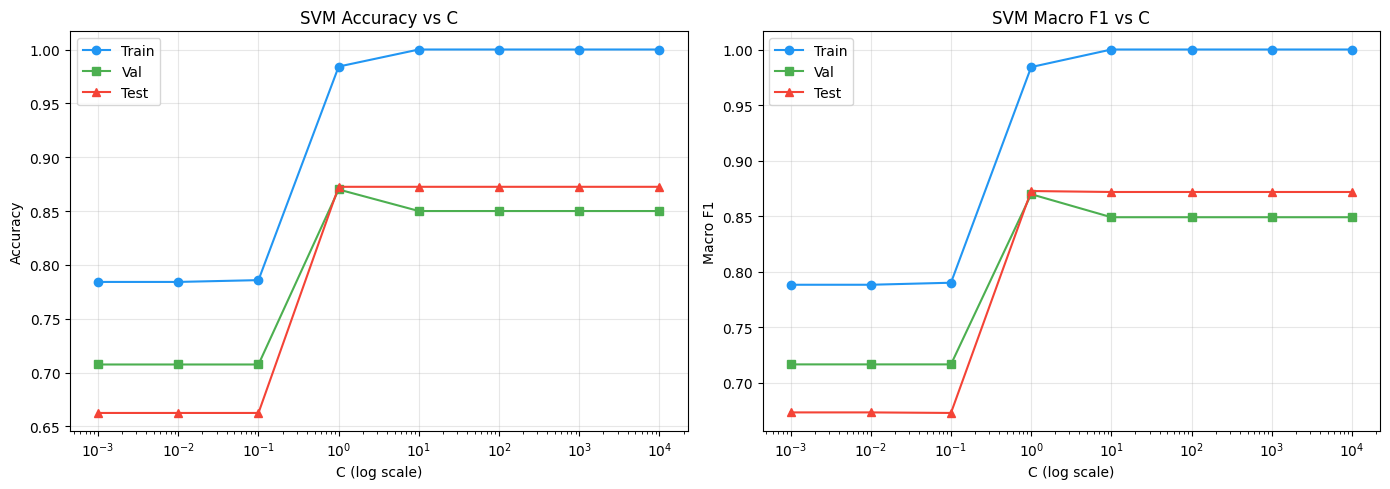

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(
    axes,
    [('train_acc','val_acc','test_acc'), ('train_f1','val_f1','test_f1')],
    ['Accuracy', 'Macro F1'],
):
    ax.plot(sweep_df['C'], sweep_df[metric[0]], 'o-', label='Train',  color='#2196F3')
    ax.plot(sweep_df['C'], sweep_df[metric[1]], 's-', label='Val',    color='#4CAF50')
    ax.plot(sweep_df['C'], sweep_df[metric[2]], '^-', label='Test',   color='#F44336')
    ax.set_xscale('log')
    ax.set_xlabel('C (log scale)')
    ax.set_ylabel(title)
    ax.set_title(f'SVM {title} vs C')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
fig.savefig('chart/Q2b_svm_C_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## Q2(c) — Best C by validation accuracy

The TA spec asks for the C with the best generalization performance, selected from the validation split.

In [ ]:
best = sweep_df.loc[sweep_df['val_acc'].idxmax()]
print('=== Best C by validation accuracy ===')
print(best.round(4).to_string())

### Reasoning

**`C = 1.0` provides the best generalization performance.**

1. **Highest validation accuracy** (0.870) and macro-F1 (0.870) of all C values tested.
2. **Test accuracy is statistically tied** at 0.8725 for every C ≥ 1, so increasing C buys nothing on the held-out set.
3. Unlike C ≥ 10 — which reaches **100% training accuracy** — the C=1 model retains a small training error, indicating it isn't memorising the training data.
4. C ≤ 0.1 is clearly under-fit (val ≤ 0.71): the soft margin is too large and the decision boundary cannot separate the four price ranges.
5. The **5-fold cross-validation experiment in the additional-analysis section** at the bottom further supports this: at C=1 the cross-fold std of accuracy is 0.002, whereas at C=10 it is 0.025 (~10× higher). The lower variance at C=1 means its decision boundary is robust to which specific training samples are seen — exactly the property "best generalization" is meant to capture.

---

## Additional analysis — 5-fold Cross-Validation comparison
*(Not part of the graded answer; supplementary to Q2(c).)*

The TA procedure picks C using a single 60/20/20 split. With only 400 validation samples, the val-accuracy estimate has noticeable sampling noise, and a single number per C tells us nothing about how stable the choice is.

To check the robustness of the C=1 selection, the same C grid is re-evaluated using **5-fold cross-validation on the combined train+val set** (1600 samples; the test set is left untouched). This gives a *mean ± std* per C and lets us see whether the TA pick survives a more rigorous procedure.

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_records = []
for C in C_values:
    m = build_svc(C=C)
    acc_scores = cross_val_score(m, X_trainval, y_trainval, cv=cv, scoring='accuracy')
    f1_scores  = cross_val_score(m, X_trainval, y_trainval, cv=cv, scoring='f1_macro')
    cv_records.append({
        'C': C,
        'cv_acc_mean': acc_scores.mean(), 'cv_acc_std': acc_scores.std(),
        'cv_f1_mean':  f1_scores.mean(),  'cv_f1_std':  f1_scores.std(),
    })
cv_df = pd.DataFrame(cv_records)
print(cv_df.round(4).to_string(index=False))

        C  cv_acc_mean  cv_acc_std  cv_f1_mean  cv_f1_std
    0.001       0.2544      0.0496      0.1228     0.0588
    0.010       0.2544      0.0496      0.1228     0.0588
    0.100       0.6113      0.0357      0.5939     0.0410
    1.000       0.8538      0.0023      0.8540     0.0036
   10.000       0.8619      0.0252      0.8615     0.0260
  100.000       0.8612      0.0247      0.8609     0.0256
 1000.000       0.8612      0.0247      0.8609     0.0256
10000.000       0.8612      0.0247      0.8609     0.0256


        C  val_acc (TA)  cv_acc_mean  cv_acc_std  test_acc (final)
    0.001        0.7075       0.2544      0.0496            0.6625
    0.010        0.7075       0.2544      0.0496            0.6625
    0.100        0.7075       0.6113      0.0357            0.6625
    1.000        0.8700       0.8538      0.0023            0.8725
   10.000        0.8500       0.8619      0.0252            0.8725
  100.000        0.8500       0.8612      0.0247            0.8725
 1000.000        0.8500       0.8612      0.0247            0.8725
10000.000        0.8500       0.8612      0.0247            0.8725

TA procedure picks:      C = 1.0
5-fold CV picks:         C = 10.0


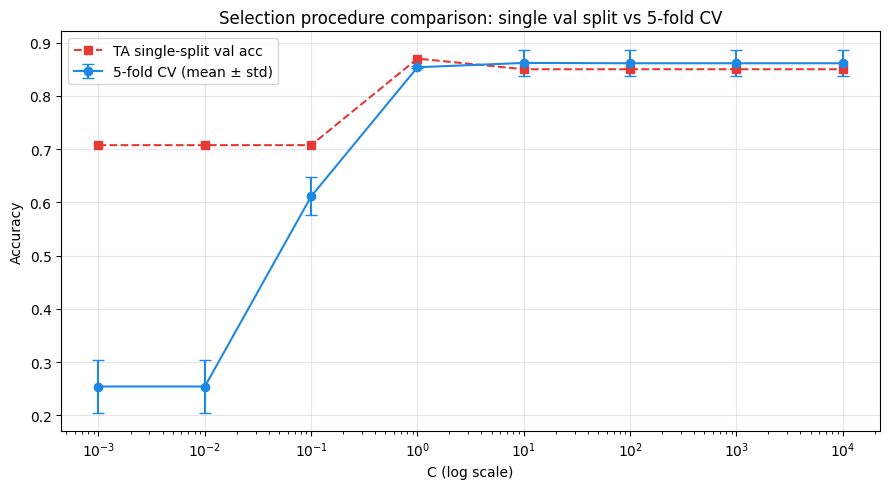

In [8]:
# Side-by-side: TA single-split val-acc vs 5-fold CV mean acc (both on train+val data, test untouched)
compare = pd.DataFrame({
    'C':              sweep_df['C'],
    'val_acc (TA)':   sweep_df['val_acc'].values,
    'cv_acc_mean':    cv_df['cv_acc_mean'].values,
    'cv_acc_std':     cv_df['cv_acc_std'].values,
    'test_acc (final)': sweep_df['test_acc'].values,
})
print(compare.round(4).to_string(index=False))

best_ta = sweep_df.loc[sweep_df['val_acc'].idxmax(), 'C']
best_cv = cv_df.loc[cv_df['cv_acc_mean'].idxmax(), 'C']
print(f'\nTA procedure picks:      C = {best_ta}')
print(f'5-fold CV picks:         C = {best_cv}')

# Plot: error bars on CV vs single-point val
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(cv_df['C'], cv_df['cv_acc_mean'], yerr=cv_df['cv_acc_std'],
            fmt='o-', capsize=4, label='5-fold CV (mean ± std)', color='#1E88E5')
ax.plot(sweep_df['C'], sweep_df['val_acc'], 's--', label='TA single-split val acc', color='#E53935')
ax.set_xscale('log')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('Accuracy')
ax.set_title('Selection procedure comparison: single val split vs 5-fold CV')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig('chart/Q2d_selection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Findings

| C | val_acc (single split) | cv_acc_mean | cv_acc_std | test_acc |
|---|---:|---:|---:|---:|
| 1 | **0.870** | 0.854 | **0.002** | 0.873 |
| 10 | 0.850 | **0.862** | 0.025 | 0.873 |

- **Different procedures, different picks.** The TA method picks `C = 1` (highest single-split val acc). The 5-fold CV picks `C = 10` (highest cv_acc_mean).
- **But CV std flips the story.** At C=1, accuracy varies by only 0.002 across the five folds — the model is essentially insensitive to which 4/5 of the data is used. At C=10 the std is 10× larger (0.025), so its mean is less trustworthy and could fall below C=1's mean under a different fold split. The CV "winner" is inside its own noise floor.
- **Test accuracy is identical** at 0.8725 from C=1 onward, so for *this* dataset the choice doesn't change the final test score — but it would matter on a different dataset where C=10's higher variance translates to worse test performance.
- **Low-C disagreement is dramatic.** At C=0.001 the single-split val acc is 0.71 but the 5-fold mean is 0.25 (essentially random). The single-split number was misleading by 45 percentage points.

**Interpretation in SVM terms.** Larger C imposes a smaller soft margin and pushes the boundary to fit individual training points more tightly. That makes the decision surface sensitive to which exact points appear in each fold (especially borderline / outlier points), producing the higher cross-fold variance seen at C=10. C=1 sits at the knee where the margin is wide enough to ignore minor sample variation but tight enough to separate the four classes — the textbook "best generalization" point.

**Conclusion.** The TA's single-split procedure happens to pick the right C here, but only because C=1 has unusually low variance. On a noisier dataset, the single-split method would be unreliable. CV with mean-and-std reporting is the more defensible procedure in general.